# G3b. Train on Synthetic, Test on Real, underperformance task

**Authors:** Ivo Rambaldi and Tommaso Petrelli

**Course:** Ethics in Artificial Intelligence, University of Bologna, a.y. 2025-2026

## What this notebook does

It answers the project's central question for the **underperformance task**: how much accuracy
and how much fairness are lost when a classifier is trained on synthetic data instead of on real
data, and tested on the same real students either way.

Marrero et al. show that a model built on circumstances is biased in opposite directions
depending on which tail it predicts, so this is not a robustness check on G3. It is the other
half of the result.

## The design

Every classifier is fitted once per training set, the real one or one of the synthetic ones, and
always scored against the same held out real test set. The test set is never synthetic and is
used for nothing but scoring, so any difference between two rows is attributable to the training
data alone.

The grid is 5 training sets by 3 classifiers, with hyperparameters fixed throughout. G4 loads
what this notebook saves rather than refitting it, so the project rests on one baseline.

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import pandas as pd

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")

from src.utils import check_prerequisites, get_logger, load_config, notebook_dirs, select_task

logger = get_logger("G3")
check_prerequisites()

# This is the only cell that differs between this notebook and its twin.
TASK = "low_perf"

cfg = select_task(load_config(PROJECT_ROOT / "config" / "config.yaml"), TASK)
RESULTS_DIR, FIGURES_DIR = notebook_dirs(cfg, f"g3/{TASK}")

TARGET = cfg["dataset"]["target_column"]
METHODS = cfg["generation"]["datasets"]
CLASSIFIERS = list(cfg["experiments"]["classifiers"])
BASELINE = cfg["experiments"]["baseline_label"]

print(f"task        : {TASK}, predicting {TARGET}")
print(f"training on : {[BASELINE] + METHODS}")
print(f"classifiers : {CLASSIFIERS}")
print(f"results     : {RESULTS_DIR}")

Prerequisites: 16 satisfied, 0 missing, 0 mismatched.
task        : low_perf, predicting target_low_perf
training on : ['real', 'ctgan', 'tvae', 'gaussian_copula', 'smote_low_perf']
classifiers : ['logistic_regression', 'xgboost', 'mlp']
results     : C:\Users\tomma\Desktop\petrellirambaldi2526\results\g3\low_perf


## 2. Data

The real splits come from G1 and the synthetic training sets from G2. The feature encoders are
fitted once on the real training set and applied unchanged to everything else, so a synthetic
dataset is never given the advantage of its own scaling.

In [2]:
from src.data.loader import load_real_data, load_synthetic_dataset
from src.data.preprocessing import get_feature_columns
from src.data.preprocessor import DataSplit, apply_feature_encoders, fit_feature_encoders

real_train, real_test = load_real_data(cfg)
synthetic_raw = {m: load_synthetic_dataset(cfg, m) for m in METHODS}

FEATURES = get_feature_columns(real_train, cfg)
PROTECTED = [c for c in cfg["dataset"]["protected_attributes"] if c in real_train.columns]

encoder, scaler, cat_cols, num_cols = fit_feature_encoders(real_train[FEATURES])


def encode(df):
    aligned = pd.DataFrame({c: df[c] for c in FEATURES}, index=df.index)
    return apply_feature_encoders(aligned, encoder, scaler, cat_cols, num_cols)


split = DataSplit(
    X_train=encode(real_train),
    X_test=encode(real_test),
    y_train=real_train[TARGET].astype(int),
    y_test=real_test[TARGET].astype(int),
    protected_train=real_train[PROTECTED],
    protected_test=real_test[PROTECTED],
    feature_names=FEATURES,
    target_name=TARGET,
    protected_attrs=PROTECTED,
)

print(f"real train {split.X_train.shape}, real test {split.X_test.shape}")
print(f"{len(PROTECTED)} circumstances available for the fairness measurement")

2026-08-01 22:00:27 | INFO     | src.data.loader | Loading real splits from C:\Users\tomma\Desktop\petrellirambaldi2526\Data\train.csv and C:\Users\tomma\Desktop\petrellirambaldi2526\Data\test.csv


2026-08-01 22:00:28 | INFO     | src.data.loader | Loading synthetic data [ctgan] from C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\ctgan\synthetic_ctgan.csv


2026-08-01 22:00:28 | INFO     | src.data.loader | Loading synthetic data [tvae] from C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\tvae\synthetic_tvae.csv


2026-08-01 22:00:28 | INFO     | src.data.loader | Loading synthetic data [gaussian_copula] from C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\copula\synthetic_copula.csv


2026-08-01 22:00:28 | INFO     | src.data.loader | Loading synthetic data [smote_low_perf] from C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\smote_low_perf\synthetic_smote_low_perf.csv


2026-08-01 22:00:29 | INFO     | src.data.preprocessing | Feature set: 38 columns


real train (58128, 38), real test (14533, 38)
13 circumstances available for the fairness measurement


### 2.1 Positive rates in the training sets

The classifiers correct for imbalance internally, through `class_weight` for logistic regression
and the MLP and `scale_pos_weight` for XGBoost. That does not make the differences below
harmless: a training set whose positive rate is far from the real one is teaching a different
problem from the one being tested.

In [3]:
balance = [{"dataset": "real train", "rows": len(real_train),
            "positive rate": real_train[TARGET].mean()},
           {"dataset": "real test", "rows": len(real_test),
            "positive rate": real_test[TARGET].mean()}]
for method, df in synthetic_raw.items():
    balance.append({"dataset": method, "rows": len(df), "positive rate": df[TARGET].mean()})

balance_df = pd.DataFrame(balance)
balance_df["positive rate"] = balance_df["positive rate"].map("{:.1%}".format)
print(balance_df.to_string(index=False))

        dataset  rows positive rate
     real train 58128         25.0%
      real test 14533         25.1%
          ctgan 58128         23.6%
           tvae 58128         27.0%
gaussian_copula 58128         25.0%
 smote_low_perf 87192         50.0%


## 3. The TSTR grid

For each classifier the real baseline is fitted first, then the same classifier is refitted on
each synthetic training set. Utility, per attribute fairness, the mean fairness across attributes
and the distance from the real features are recorded for every combination.

In [4]:
from src.evaluation.evaluator import Evaluator

evaluator = Evaluator(split, cfg)
rows, per_attribute = [], {}

for classifier in CLASSIFIERS:
    baseline = evaluator.baseline(classifier)
    rows.append({"method": BASELINE, "classifier": classifier, **baseline, "mmd": 0.0})
    per_attribute[(BASELINE, classifier)] = evaluator.last_fairness_detail

    for method, df in synthetic_raw.items():
        result = evaluator.evaluate(encode(df), df[TARGET].astype(int), classifier, method)
        rows.append(result)
        per_attribute[(method, classifier)] = evaluator.last_fairness_detail

metrics = pd.DataFrame(rows)
lead = ["method", "classifier", "balanced_accuracy", "f1_macro", "roc_auc", "brier_score", "mmd"]
metrics = metrics[lead + [c for c in metrics.columns if c not in lead]]
print(f"\nGrid complete: {metrics.shape[0]} rows")

2026-08-01 22:00:29 | INFO     | src.evaluation.evaluator | Real data baseline for [logistic_regression]


2026-08-01 22:00:30 | INFO     | src.evaluation.evaluator |   [real] AUC=0.6878 BA=0.6327


2026-08-01 22:00:30 | INFO     | src.evaluation.evaluator | Evaluating [ctgan | logistic_regression]


2026-08-01 22:00:30 | INFO     | src.evaluation.evaluator |   [synthetic] AUC=0.6535 BA=0.6126


2026-08-01 22:00:34 | INFO     | src.evaluation.evaluator | Evaluating [tvae | logistic_regression]


...

2026-08-01 22:01:59 | INFO     | src.evaluation.evaluator | Evaluating [gaussian_copula | mlp]


2026-08-01 22:02:12 | INFO     | src.evaluation.evaluator |   [synthetic] AUC=0.5682 BA=0.5005


2026-08-01 22:02:15 | INFO     | src.evaluation.evaluator | Evaluating [smote_low_perf | mlp]


2026-08-01 22:02:39 | INFO     | src.evaluation.evaluator |   [synthetic] AUC=0.6592 BA=0.5510



Grid complete: 15 rows


In [5]:
print(metrics[["method", "classifier", "balanced_accuracy", "f1_macro", "roc_auc",
               "mean_dpd", "mean_eod", "mean_di", "mean_odds_ratio",
               "degenerate_predictions"]].round(4).to_string(index=False))

         method          classifier  balanced_accuracy  f1_macro  roc_auc  mean_dpd  mean_eod  mean_di  mean_odds_ratio  degenerate_predictions
           real logistic_regression             0.6327    0.5846   0.6878    0.3191    0.3397   0.4227           2.3820                   False
          ctgan logistic_regression             0.6126    0.5447   0.6535    0.3625    0.3700   0.4361           3.1237                   False
           tvae logistic_regression             0.6079    0.5470   0.6450    0.3505    0.3663   0.4070           2.4768                   False
gaussian_copula logistic_regression             0.5974    0.5522   0.6336    0.2276    0.2314   0.5601           1.5905                   False
 smote_low_perf logistic_regression             0.5505    0.5524   0.6180    0.1233    0.1369   0.5163           2.1887                   False
           real             xgboost             0.6466    0.5959   0.7100    0.2904    0.3242   0.4189           2.4688                 

### 3.1 Change from the real baseline

Each synthetic row is compared against the real row for the same classifier, which removes the
classifier's own strength from the picture.

Deltas are synthetic minus real throughout the project. On balanced accuracy, F1, AUC and DI,
where higher is better, a negative delta means the synthetic training set made the model worse.
On DPD, EOD and the Brier score, where lower is better, a negative delta means it made it
better.

In [6]:
from src.evaluation.delta import (
    compute_delta_matrix,
    get_fairness_delta_columns,
    get_utility_delta_columns,
)

deltas = compute_delta_matrix(metrics, cfg)
utility_delta_cols = get_utility_delta_columns(deltas)
fairness_delta_cols = get_fairness_delta_columns(deltas)

synthetic_deltas = deltas[deltas["method"] != BASELINE]
print(synthetic_deltas[["method", "classifier"] + utility_delta_cols + fairness_delta_cols]
      .round(4).to_string(index=False))

         method          classifier  delta_balanced_accuracy  delta_f1_macro  delta_roc_auc  delta_brier_score  delta_mean_dpd  delta_mean_eod  delta_mean_di  delta_mean_odds_ratio
          ctgan logistic_regression                  -0.0201         -0.0399        -0.0343             0.0089          0.0433          0.0303         0.0134                 0.7416
           tvae logistic_regression                  -0.0247         -0.0377        -0.0428             0.0633          0.0313          0.0265        -0.0157                 0.0948
gaussian_copula logistic_regression                  -0.0353         -0.0324        -0.0543             0.0142         -0.0915         -0.1083         0.1374                -0.7915
 smote_low_perf logistic_regression                  -0.0822         -0.0323        -0.0699            -0.0107         -0.1958         -0.2028         0.0936                -0.1934
          ctgan             xgboost                  -0.0349         -0.0248        -0.0654    

In [7]:
from src.data.persistence import save_csv

save_csv(metrics, RESULTS_DIR / "metrics_matrix.csv")
save_csv(deltas, RESULTS_DIR / "delta_matrix.csv")

per_attribute_dir = RESULTS_DIR / "per_attribute_fairness"
for (method, classifier), frame in per_attribute.items():
    save_csv(frame, per_attribute_dir / f"fairness_{method}_{classifier}.csv")

2026-08-01 22:02:43 | INFO     | src.data.persistence | Saved 15 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g3\low_perf\metrics_matrix.csv


2026-08-01 22:02:43 | INFO     | src.data.persistence | Saved 15 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g3\low_perf\delta_matrix.csv


2026-08-01 22:02:43 | INFO     | src.data.persistence | Saved 13 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g3\low_perf\per_attribute_fairness\fairness_real_logistic_regression.csv


2026-08-01 22:02:43 | INFO     | src.data.persistence | Saved 13 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g3\low_perf\per_attribute_fairness\fairness_ctgan_logistic_regression.csv


2026-08-01 22:02:43 | INFO     | src.data.persistence | Saved 13 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g3\low_perf\per_attribute_fairness\fairness_tvae_logistic_regression.csv


...

2026-08-01 22:02:43 | INFO     | src.data.persistence | Saved 13 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g3\low_perf\per_attribute_fairness\fairness_real_mlp.csv


2026-08-01 22:02:43 | INFO     | src.data.persistence | Saved 13 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g3\low_perf\per_attribute_fairness\fairness_ctgan_mlp.csv


2026-08-01 22:02:43 | INFO     | src.data.persistence | Saved 13 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g3\low_perf\per_attribute_fairness\fairness_tvae_mlp.csv


2026-08-01 22:02:43 | INFO     | src.data.persistence | Saved 13 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g3\low_perf\per_attribute_fairness\fairness_gaussian_copula_mlp.csv


2026-08-01 22:02:43 | INFO     | src.data.persistence | Saved 13 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g3\low_perf\per_attribute_fairness\fairness_smote_low_perf_mlp.csv


## 4. Utility

2026-08-01 22:02:49 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\balanced_accuracy.png


2026-08-01 22:02:49 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\f1_macro.png


2026-08-01 22:02:49 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\roc_auc.png


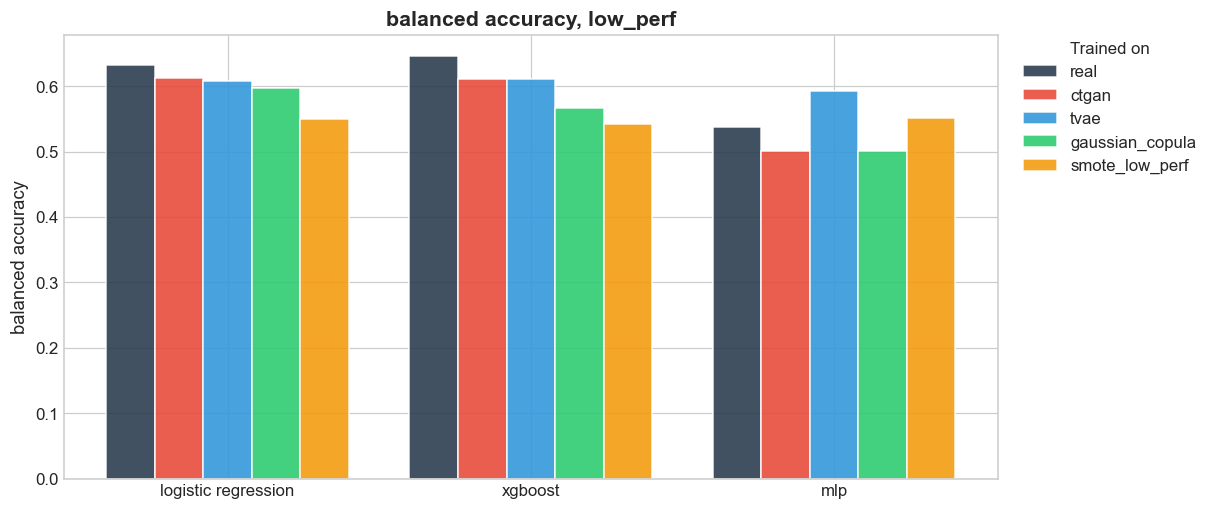

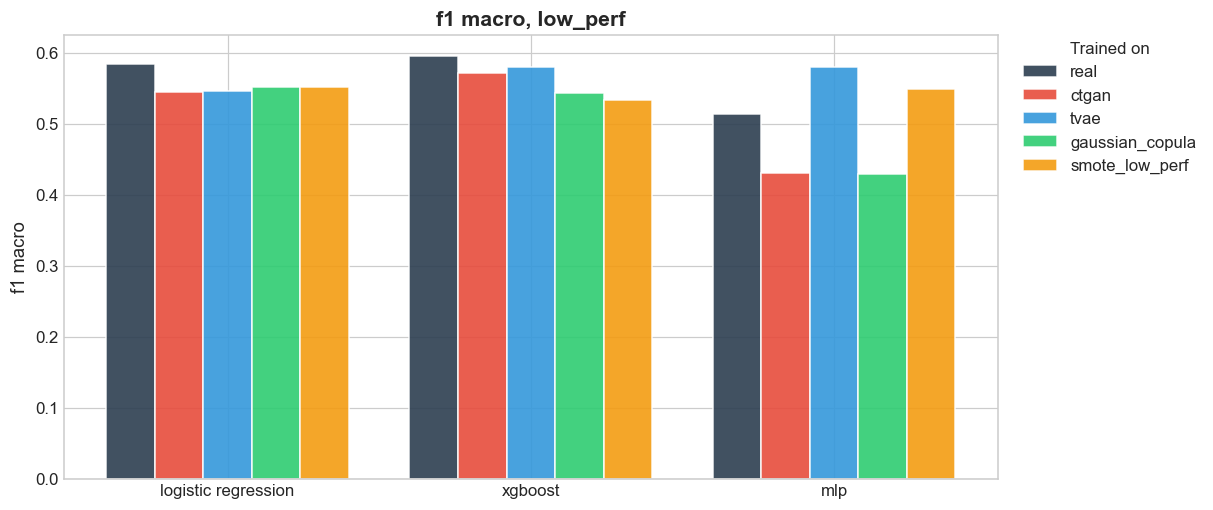

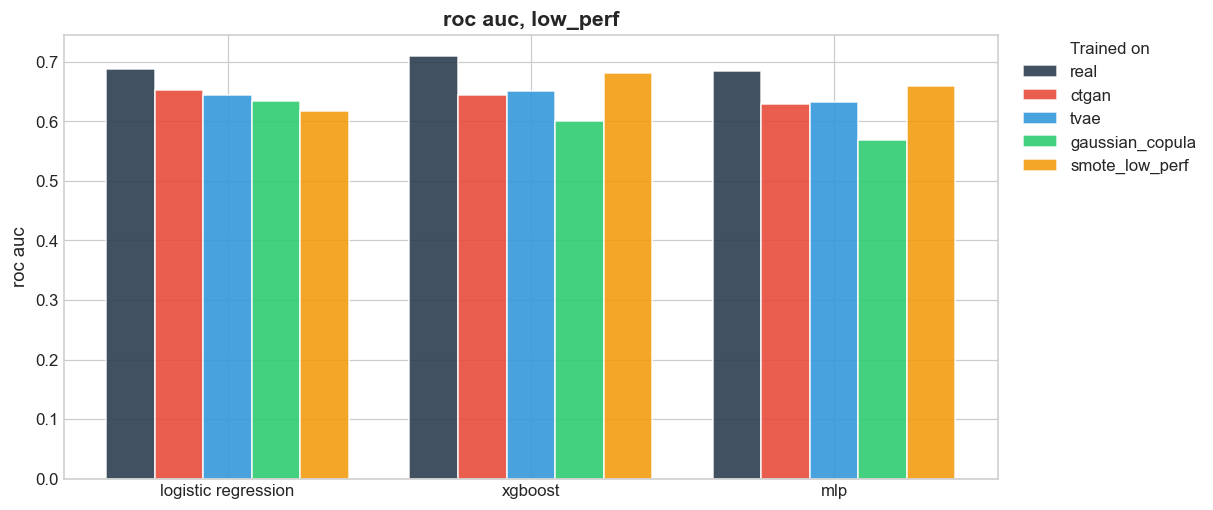

In [8]:
from src.utils.plotting import plot_metric_by_method

for metric in ["balanced_accuracy", "f1_macro", "roc_auc"]:
    plot_metric_by_method(metrics, metric, cfg, FIGURES_DIR,
                          title=f"{metric.replace('_', ' ')}, {TASK}")

In [9]:
utility_by_method = (
    metrics.groupby("method")[["balanced_accuracy", "f1_macro", "roc_auc", "brier_score", "mmd"]]
    .mean()
    .round(4)
    .sort_values("balanced_accuracy", ascending=False)
)
print("Averaged across the three classifiers:")
print(utility_by_method.to_string())

Averaged across the three classifiers:
                 balanced_accuracy  f1_macro  roc_auc  brier_score     mmd
method                                                                    
real                        0.6059    0.5650   0.6940       0.2047  0.0000
tvae                        0.6040    0.5692   0.6429       0.2700  0.0624
ctgan                       0.5750    0.5153   0.6422       0.2131  0.0023
gaussian_copula             0.5552    0.5087   0.6009       0.2203  0.0015
smote_low_perf              0.5481    0.5447   0.6530       0.1939  0.1206


In [10]:
# Reference points for the table above. Balanced accuracy is the mean of the two class
# recalls, so any classifier that ignores its input scores 0.5 whatever rate it predicts at,
# and the 25 to 75 class imbalance cannot flatter it. The other three metrics do not share
# that property and each needs its own reference.
import numpy as np

y_reference = split.y_test.to_numpy()
base_rate = y_reference.mean()
majority = np.zeros_like(y_reference)

from sklearn.metrics import balanced_accuracy_score, brier_score_loss, f1_score

print(f"test positive rate                  {base_rate:.4f}")
print(f"always predict the majority class:  balanced accuracy "
      f"{balanced_accuracy_score(y_reference, majority):.4f}, "
      f"f1 macro {f1_score(y_reference, majority, average='macro'):.4f}")
print(f"predict the base rate for everyone: brier "
      f"{brier_score_loss(y_reference, np.full(len(y_reference), base_rate)):.4f}")

test positive rate                  0.2510
always predict the majority class:  balanced accuracy 0.5000, f1 macro 0.4282
predict the base rate for everyone: brier 0.1880


**Observation.** Averaged over the three classifiers, every synthetic training set costs balanced
accuracy against the real row. The grid above shows this is not true of every single fit: on the
MLP, the weakest of the three on real data, some synthetic sets score higher.

Balanced accuracy averages the recall of each class, so a model that ignores its input scores 0.5
whatever rate it predicts at. A row near 0.5 has learned nothing, and its fairness numbers mean
nothing either. The floors printed above differ per metric: F1 macro sits near 0.43 on this class
balance, and the Brier scores are worse than a constant predictor because reweighting towards the
minority class buys recall at the cost of calibration.

### 4.1 MMD on the SMOTE file

G2 measured the whole SMOTE file and found it the closest of the five to the real data. Here it
is the furthest. Two thirds of the file is not synthetic at all, because an oversampler keeps
every original row and appends interpolated ones. Splitting the file at that boundary separates
what SMOTE copied from what it invented.

In [11]:
from src.evaluation.utility import compute_mmd

boundary = len(real_train)
smote_method = next(m for m in METHODS if m.startswith("smote"))
smote_df = synthetic_raw[smote_method]

parts = {
    "whole file, as reported above": smote_df,
    "the original rows it copied": smote_df.iloc[:boundary],
    "the rows it interpolated": smote_df.iloc[boundary:],
}
for label, part in parts.items():
    print(f"  MMD against the real training set, {label:32s} {compute_mmd(split.X_train, encode(part), cfg):.6f}")

  MMD against the real training set, whole file, as reported above    0.120554


  MMD against the real training set, the original rows it copied      0.000000


  MMD against the real training set, the rows it interpolated         0.785956


**Observation.** The copied rows sit at zero distance, because they are the real data. The
interpolated rows are further from it than anything the three model based generators produced,
and averaging the two is what made SMOTE look like the highest fidelity method in G2.

A fidelity score computed over a whole oversampled file is therefore flattered by the share of it
that was never generated, and that share is a free parameter: the more the oversampler adds, the
worse the file looks, regardless of the quality of what it adds.

## 5. Fairness

DPD, EOD and DI are computed per circumstance and then averaged. The groups come from
`config.yaml`, following Table 2 of Marrero et al.: tertiary education against the rest, high
occupation against the rest, most books against the rest, rather than a median split.

`odds_ratio` is the metric that paper leads with, the recall of the unprivileged group over the
recall of the privileged one. Below 1 the model finds the advantaged students more reliably. It
is volatile when a group has few positive cases, so it is reported alongside the others rather
than instead of them.

2026-08-01 22:03:00 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\mean_dpd.png


2026-08-01 22:03:00 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\mean_eod.png


2026-08-01 22:03:00 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\mean_di.png


2026-08-01 22:03:00 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\mean_odds_ratio.png


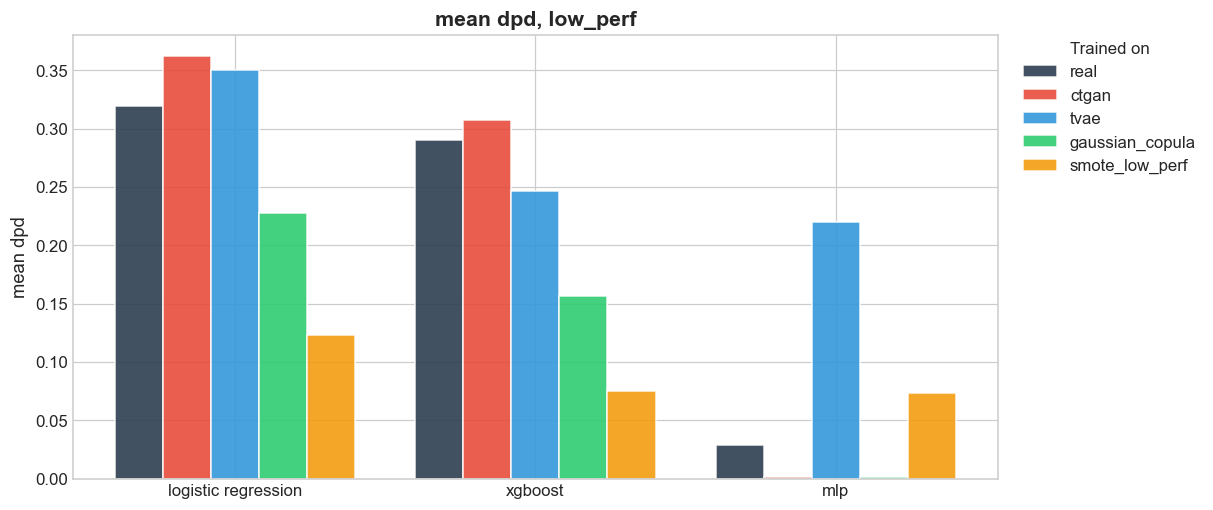

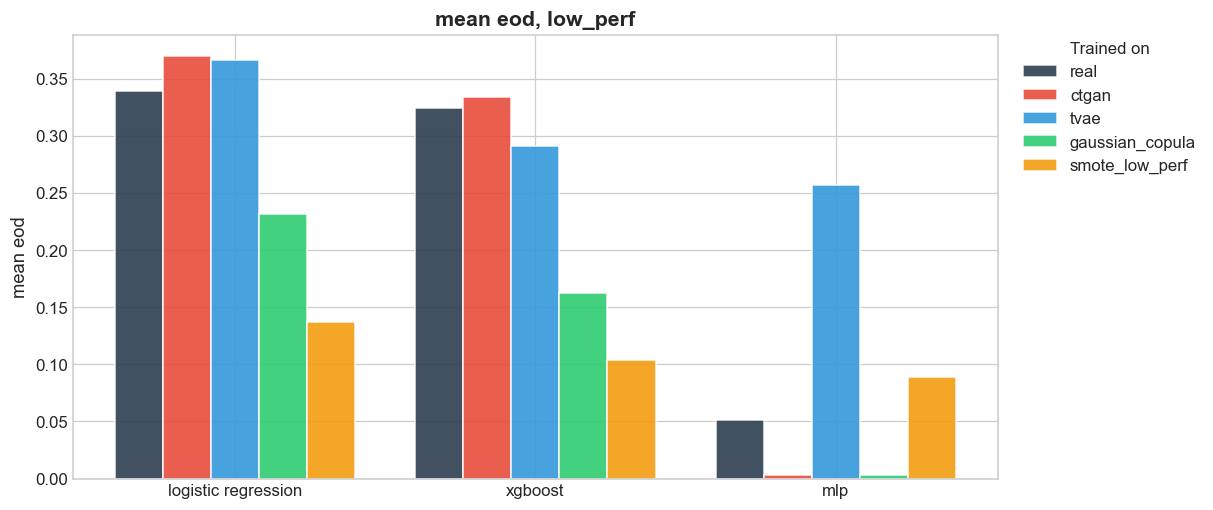

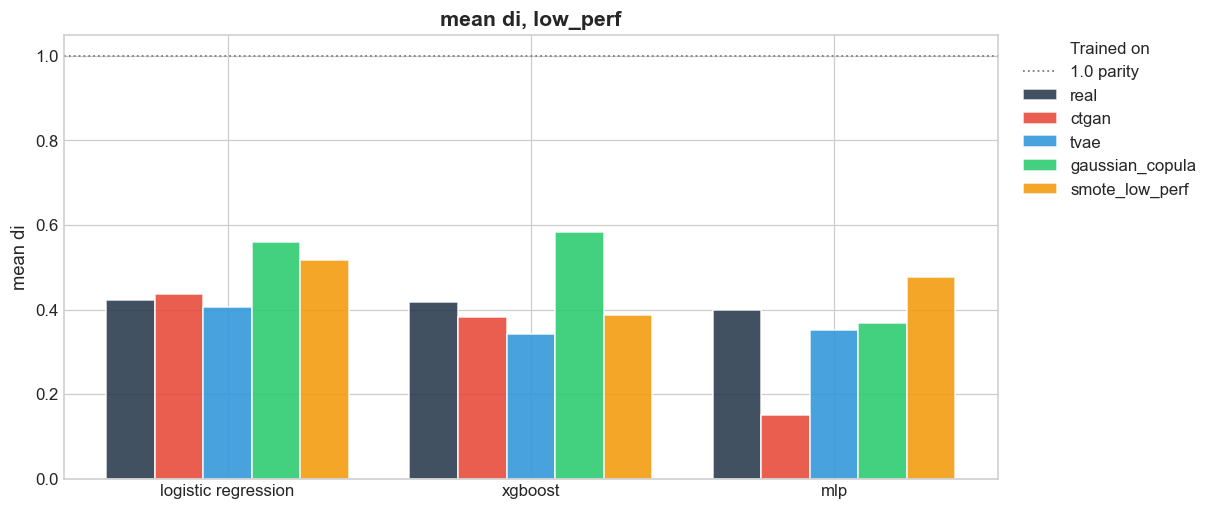

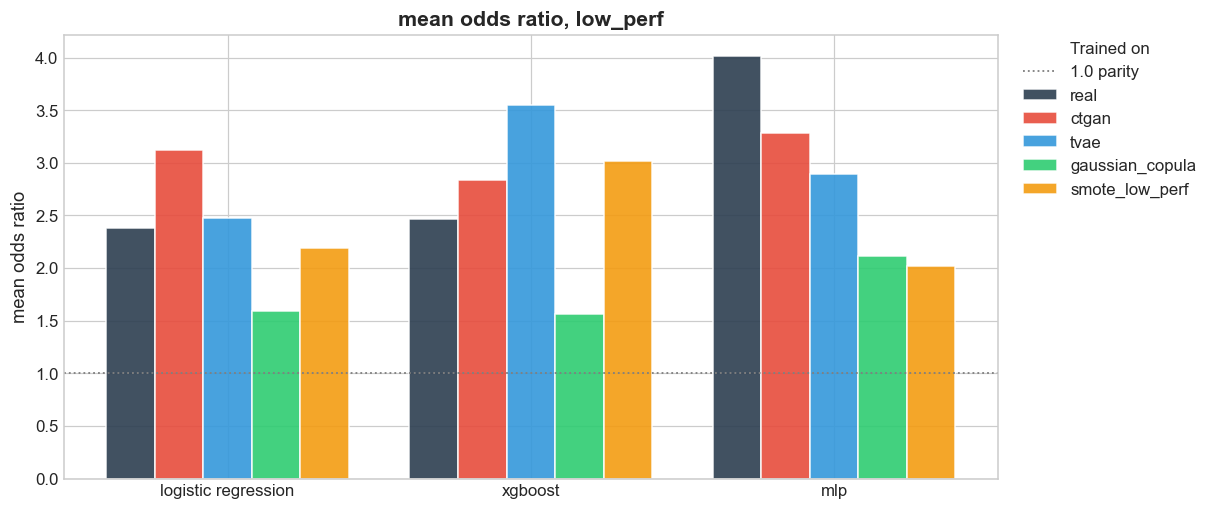

In [12]:
# The odds ratio is a ratio, so its reference is 1 rather than 0.
parity = {"mean_di": 1.0, "mean_odds_ratio": 1.0}

for metric in ["mean_dpd", "mean_eod", "mean_di", "mean_odds_ratio"]:
    plot_metric_by_method(metrics, metric, cfg, FIGURES_DIR,
                          title=f"{metric.replace('_', ' ')}, {TASK}",
                          reference_line=parity.get(metric), reference_label="1.0 parity")

In [13]:
fairness_by_method = (
    metrics.groupby("method")[["mean_dpd", "mean_eod", "mean_di", "mean_odds_ratio",
                               "balanced_accuracy", "degenerate_predictions"]]
    .mean()
    .round(4)
)
print("Averaged across the three classifiers:")
print(fairness_by_method.to_string())

Averaged across the three classifiers:
                 mean_dpd  mean_eod  mean_di  mean_odds_ratio  balanced_accuracy  degenerate_predictions
method                                                                                                  
ctgan              0.2237    0.2356   0.3234           3.0837             0.5750                     0.0
gaussian_copula    0.1284    0.1323   0.5038           1.7566             0.5552                     0.0
real               0.2129    0.2384   0.4134           2.9555             0.6059                     0.0
smote_low_perf     0.0908    0.1100   0.4605           2.4084             0.5481                     0.0
tvae               0.2726    0.3048   0.3674           2.9732             0.6040                     0.0


**Observation.** Read each synthetic row against the real row with the balanced accuracy column
beside it. A training set that lowers DPD while pushing balanced accuracy towards 0.5 has not
been made fairer but indecisive, because a model that rarely predicts the positive class
equalises positive rates across groups for free. The `degenerate_predictions` column flags the
extreme case.

`mean_odds_ratio` is the only metric here with a direction rather than a size. On the real
baseline that direction is set by the tail being predicted, and G5 counts how consistently.

### 5.1 Fairness per circumstance

The averages hide a wide spread. This drills into the classifier with the worst mean DPD for each
training set.

2026-08-01 22:03:01 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\per_attr_dpd_real_logistic_regression.png


2026-08-01 22:03:02 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\per_attr_di_real_logistic_regression.png


2026-08-01 22:03:02 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\per_attr_dpd_ctgan_logistic_regression.png


2026-08-01 22:03:02 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\per_attr_di_ctgan_logistic_regression.png


2026-08-01 22:03:02 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\per_attr_dpd_tvae_logistic_regression.png


2026-08-01 22:03:03 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\per_attr_di_tvae_logistic_regression.png


2026-08-01 22:03:03 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\per_attr_dpd_gaussian_copula_logistic_regression.png


2026-08-01 22:03:03 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\per_attr_di_gaussian_copula_logistic_regression.png


2026-08-01 22:03:04 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\per_attr_dpd_smote_low_perf_logistic_regression.png


2026-08-01 22:03:04 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\per_attr_di_smote_low_perf_logistic_regression.png


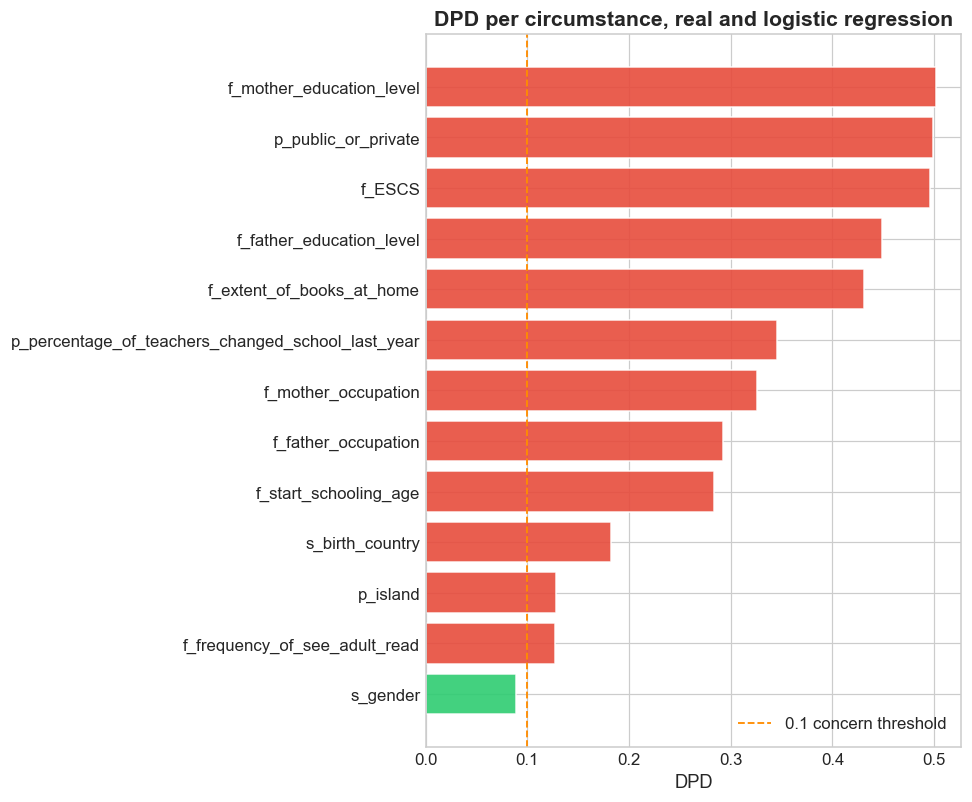

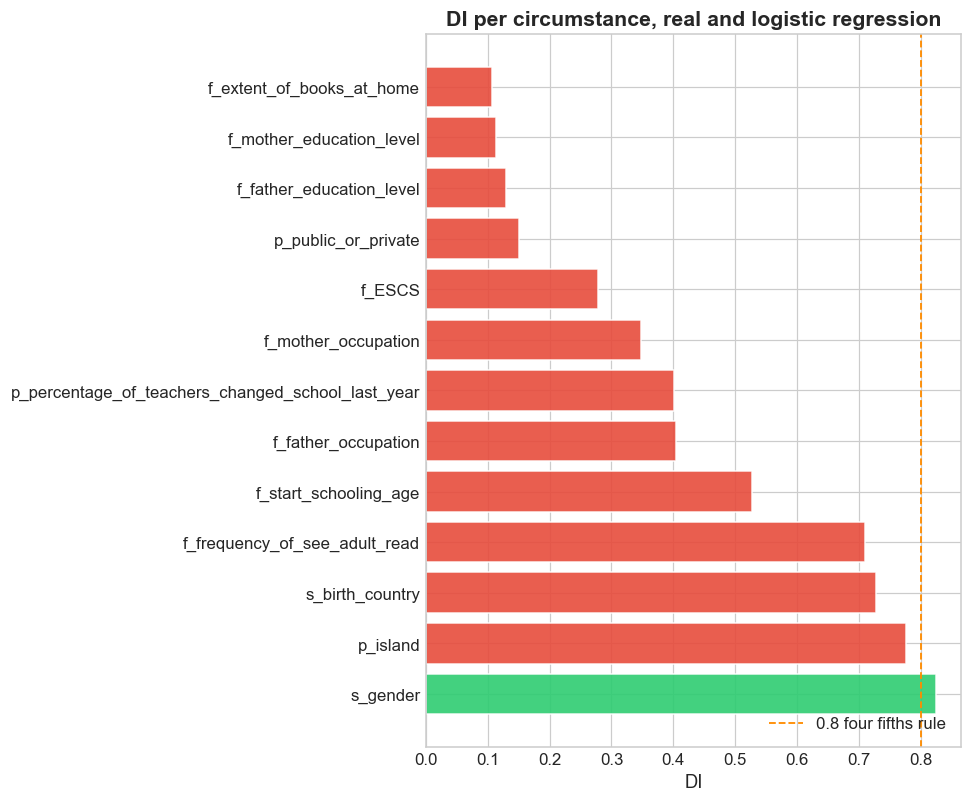

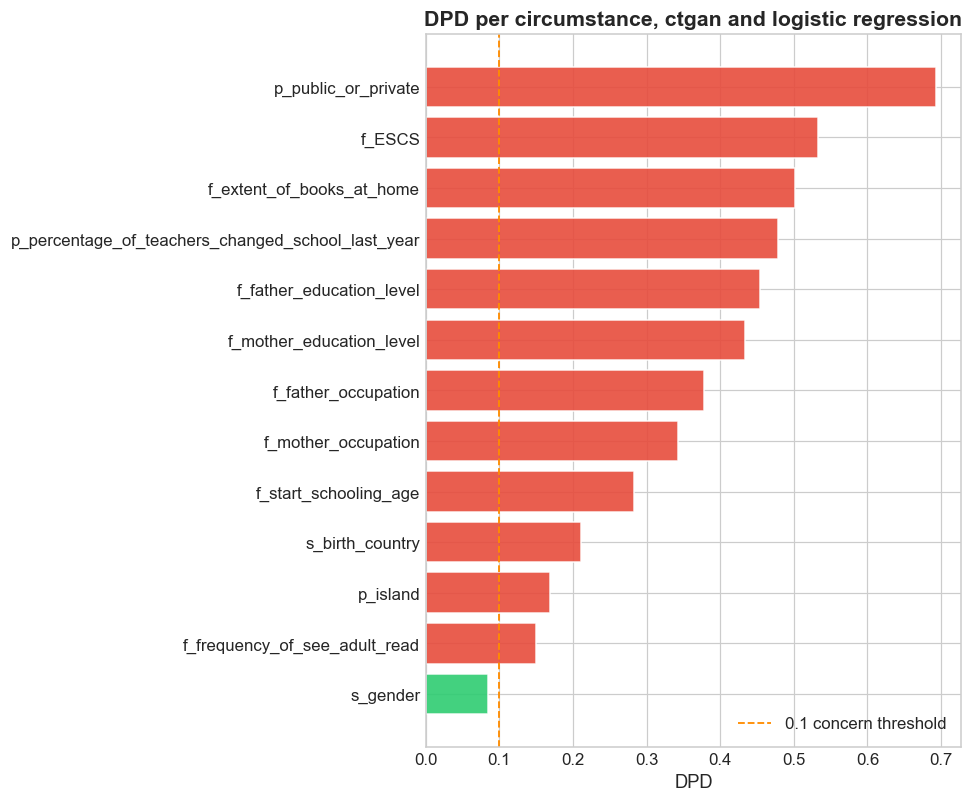

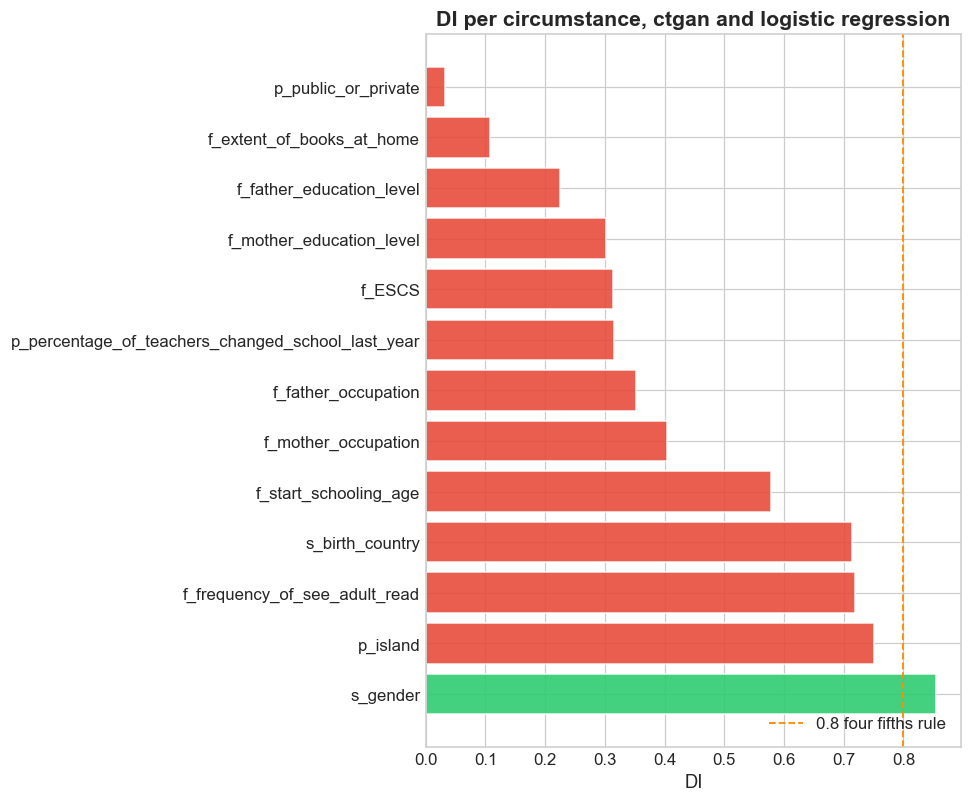

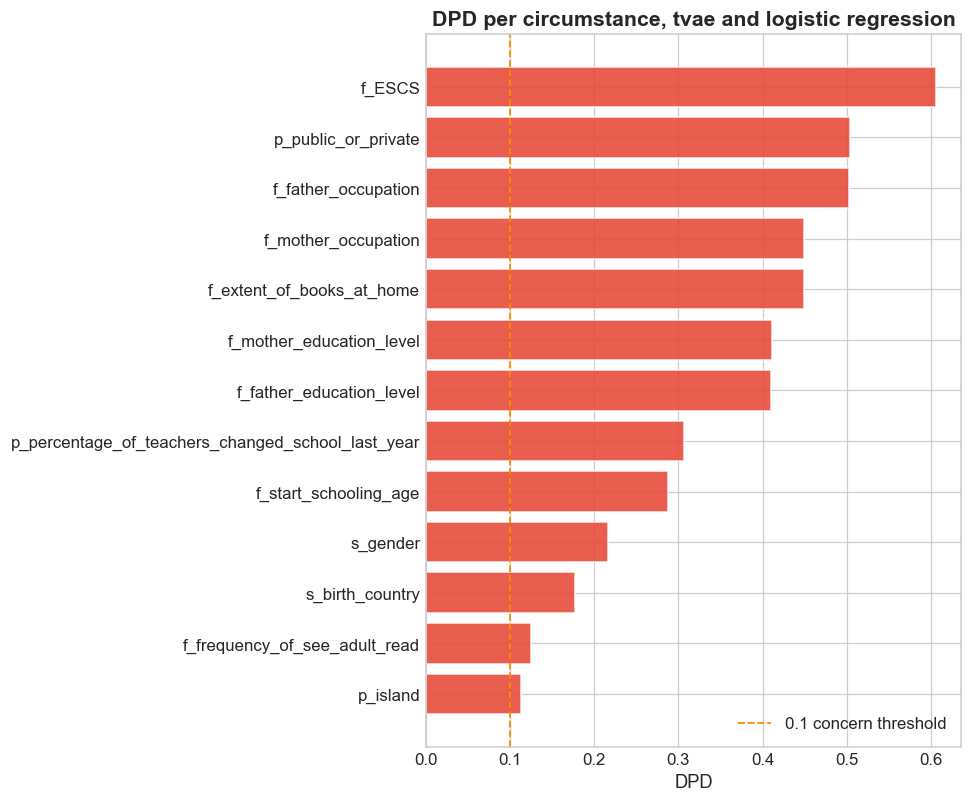

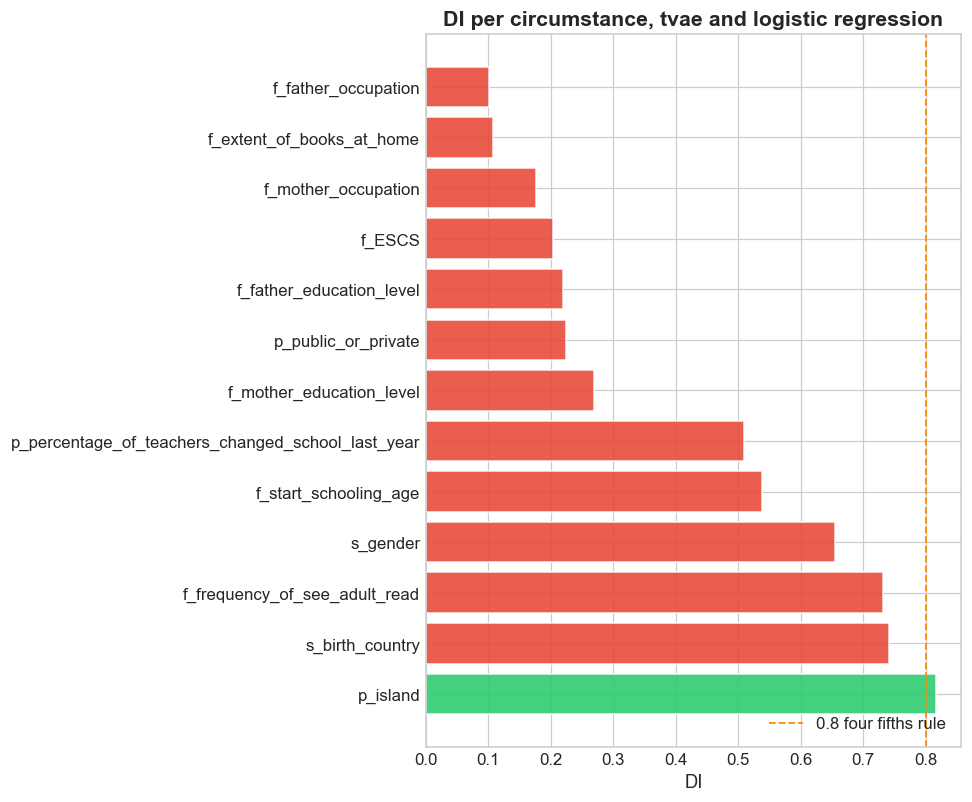

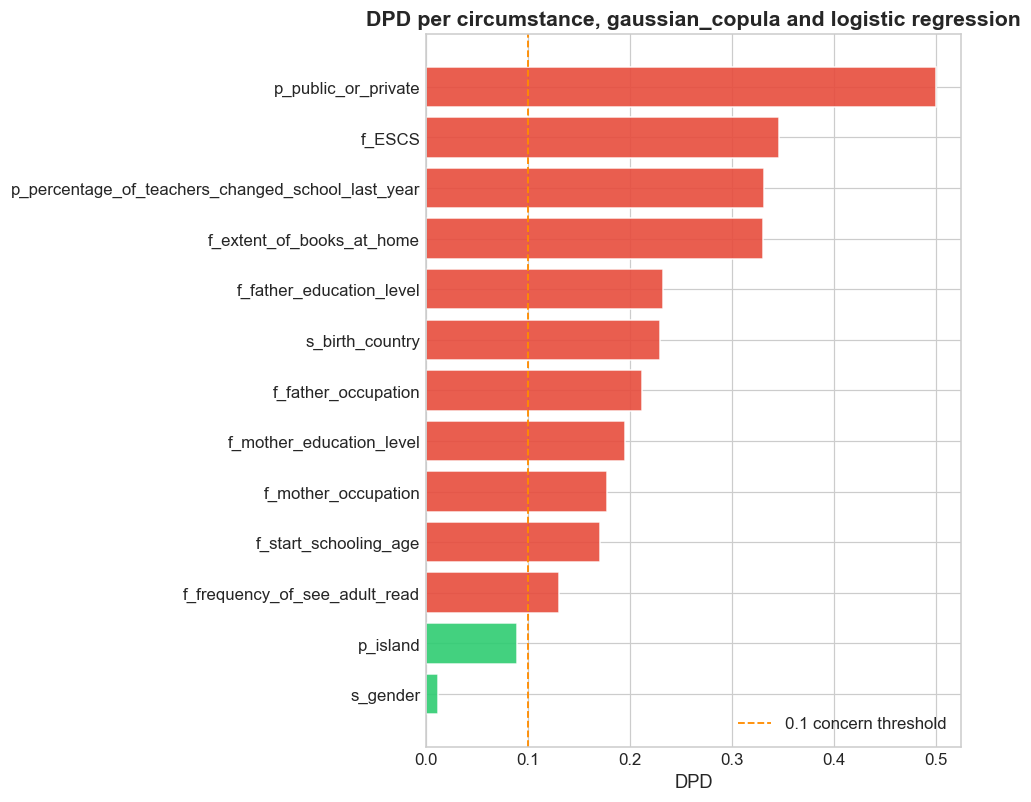

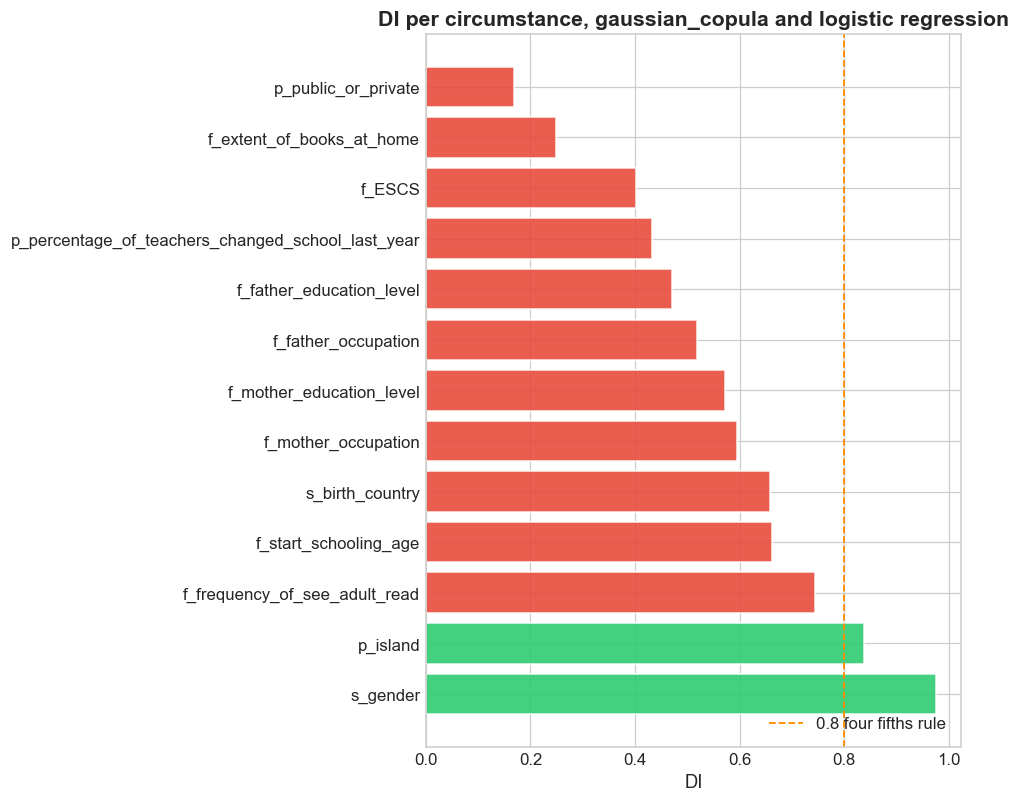

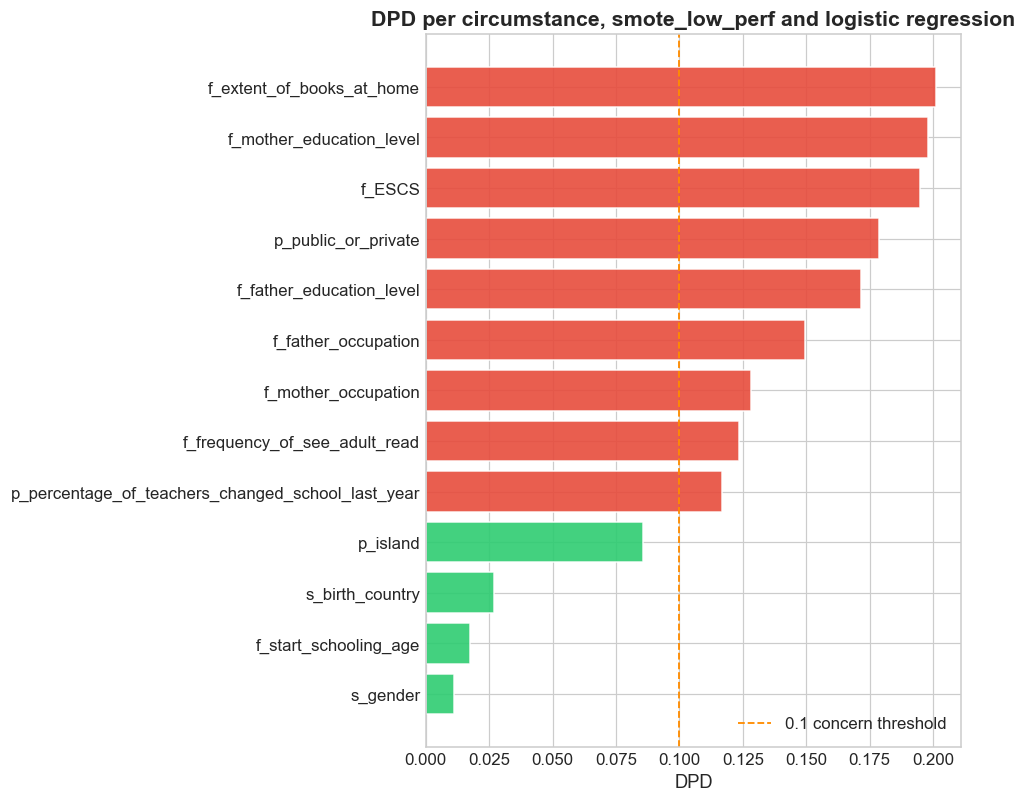

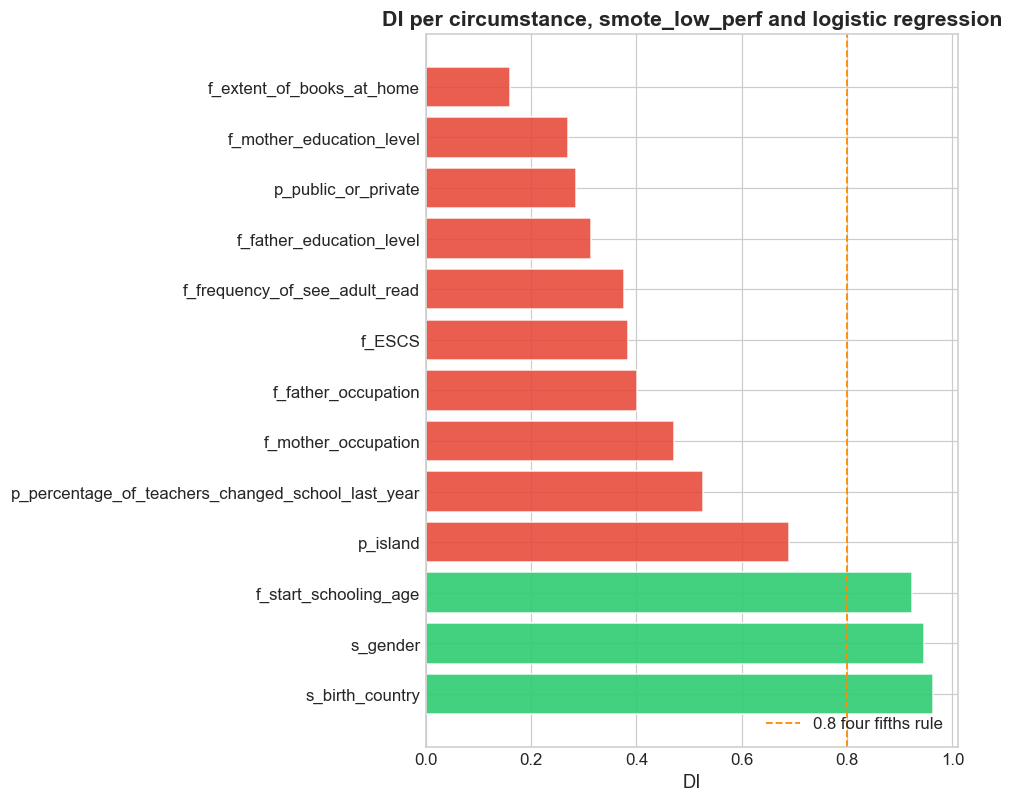

In [14]:
from src.utils.plotting import plot_per_attribute_fairness

for method in [BASELINE] + METHODS:
    subset = metrics[metrics["method"] == method]
    worst = subset.loc[subset["mean_dpd"].idxmax(), "classifier"]
    detail = per_attribute[(method, worst)]
    for metric in ["dpd", "di"]:
        plot_per_attribute_fairness(
            detail, metric, cfg, FIGURES_DIR,
            title=f"{metric.upper()} per circumstance, {method} and {worst.replace('_', ' ')}",
            name_suffix=f"_{method}_{worst}",
        )

In [15]:
real_detail = per_attribute[(BASELINE, "logistic_regression")]
print("Real baseline, logistic regression, per circumstance:")
print(real_detail[["attribute", "n_evaluated", "n_missing", "dpd", "eod", "di", "odds_ratio"]]
      .round(4).to_string(index=False))

Real baseline, logistic regression, per circumstance:
                                        attribute  n_evaluated  n_missing    dpd    eod     di  odds_ratio
                                         s_gender        14533          0 0.0892 0.0888 0.8241      1.1119
                         f_mother_education_level        10370       4163 0.5017 0.5903 0.1132      5.0860
                         f_father_education_level         9607       4926 0.4485 0.5186 0.1298      3.9113
                              f_mother_occupation         9946       4587 0.3256 0.3143 0.3481      1.8398
                              f_father_occupation         9310       5223 0.2928 0.2685 0.4049      1.6588
                                  s_birth_country         3215      11318 0.1823 0.2261 0.7270      1.0584
                            f_start_schooling_age        10466       4067 0.2834 0.2697 0.5274      1.4739
                        f_extent_of_books_at_home        10650       3883 0.4306 0.5342 0.

**Observation.** The widest gaps belong to the family circumstances, parental education and
occupation, books at home and the socioeconomic composite, which is the ordering G1 found in the
raw scores before any model existed.

`p_public_or_private` sits among them despite being a property of the school. Private schools in
this data have a much higher mean ESCS, so the column carries family advantage as well as school
effect. The circumstances that stay near parity are gender and island, neither of which tracks
socioeconomic position.

The `n_missing` column shows how few test students some circumstances are measured on, and the
fairness number itself does not say so.

## 6. Utility against fairness

2026-08-01 22:03:06 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\delta_heatmap_utility.png


2026-08-01 22:03:07 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\delta_heatmap_fairness.png


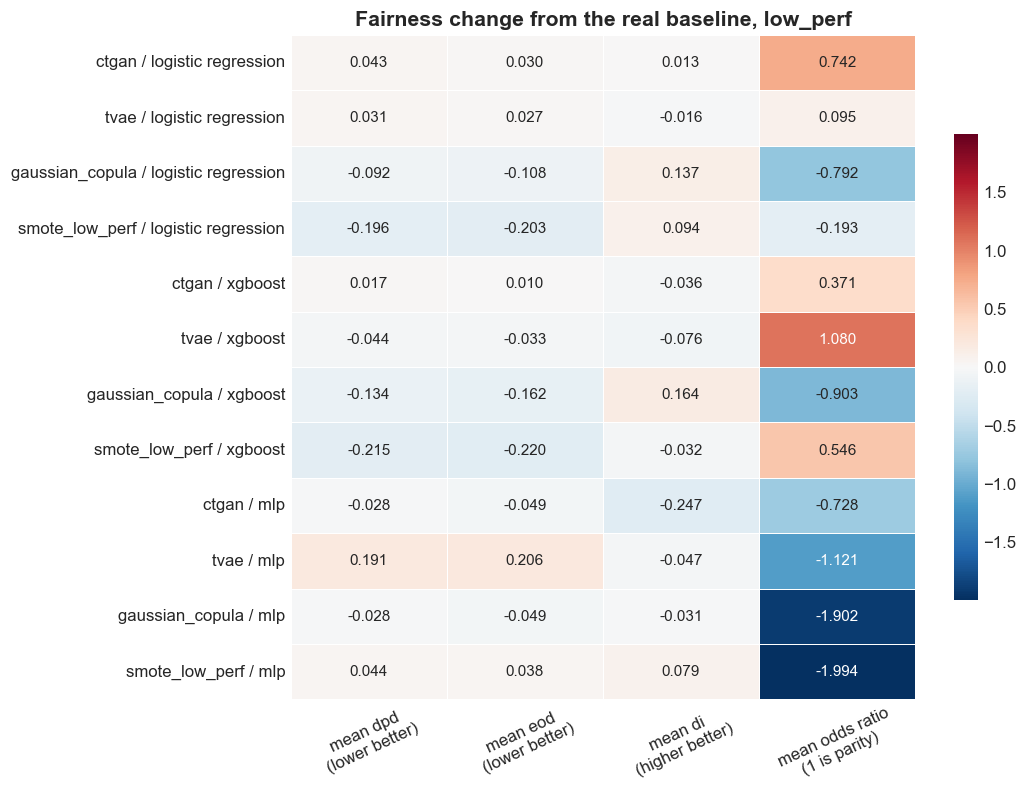

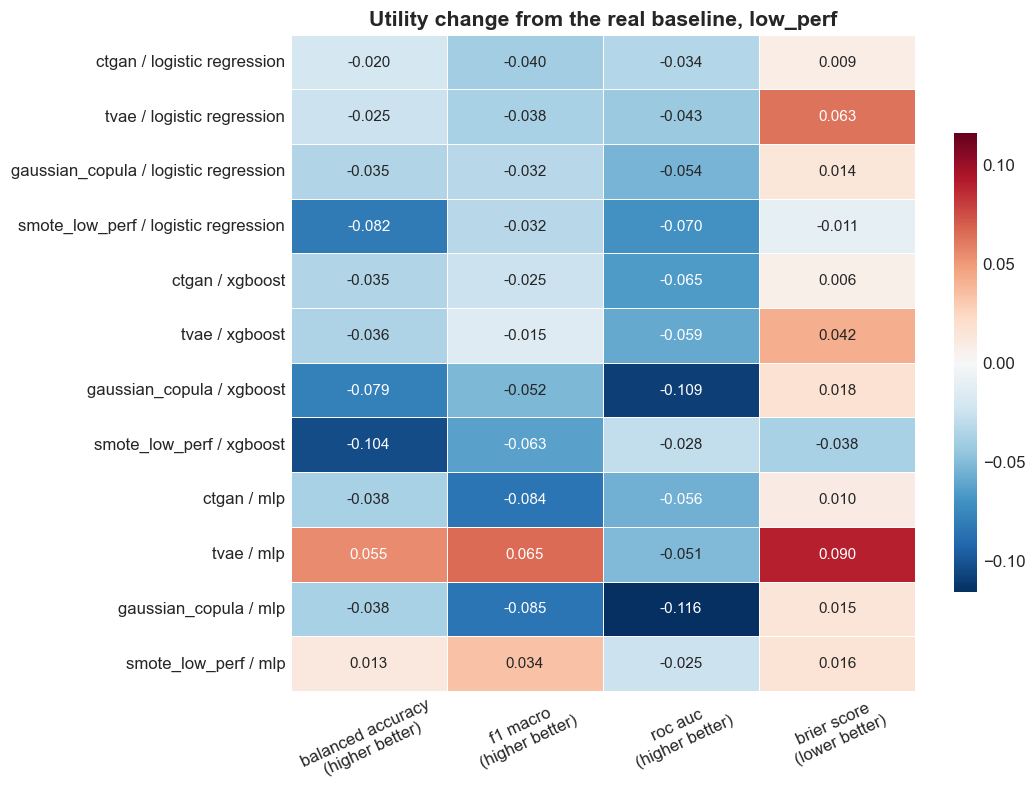

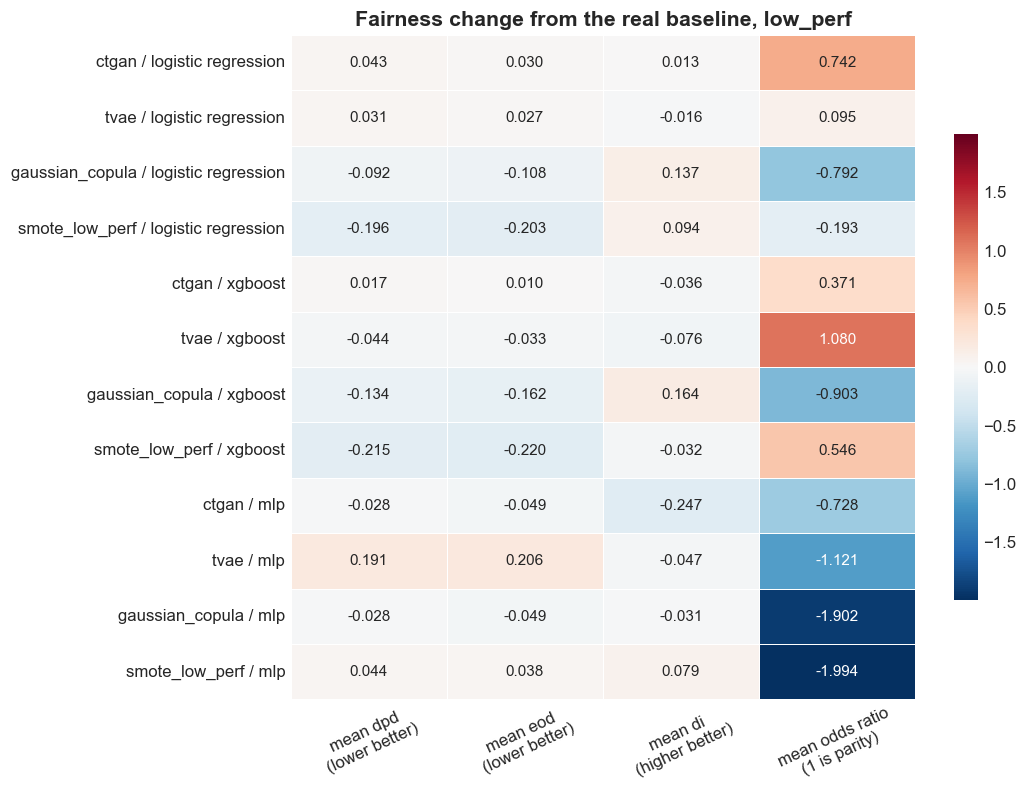

In [16]:
from src.utils.plotting import plot_delta_heatmap, plot_utility_fairness_scatter

plot_delta_heatmap(deltas, utility_delta_cols, "utility", cfg, FIGURES_DIR,
                   title=f"Utility change from the real baseline, {TASK}")
plot_delta_heatmap(deltas, fairness_delta_cols, "fairness", cfg, FIGURES_DIR,
                   title=f"Fairness change from the real baseline, {TASK}")

2026-08-01 22:03:08 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g3\low_perf\scatter_utility_vs_fairness.png


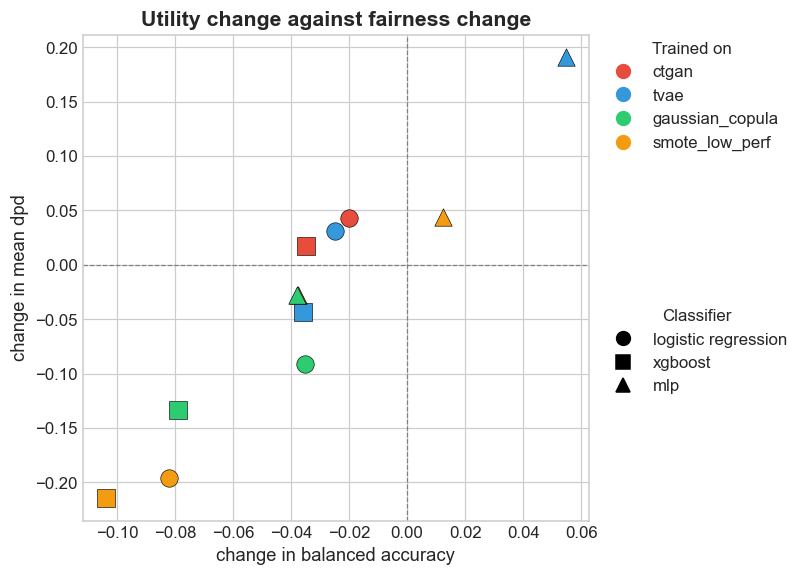

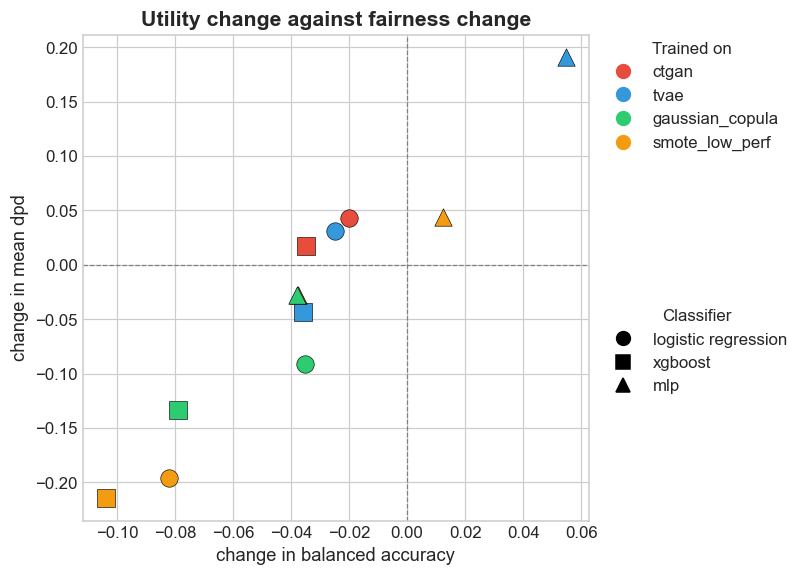

In [17]:
plot_utility_fairness_scatter(deltas, "delta_balanced_accuracy", "delta_mean_dpd",
                              cfg, FIGURES_DIR)

**Observation.** Both axes are changes from the real baseline, but the direction that counts as
better is not the same on the two. Further right is more accuracy; further down is a smaller DPD,
so closer to parity.

The quadrant a practitioner would want is therefore the bottom right, accuracy preserved and the
gap reduced. The bottom left has the same reduced gap and pays for it in accuracy, which
section 5 gives the reason not to read as a success.

## 7. Final observations

- Every synthetic training set costs utility relative to real data, by an amount that varies by
  generator and by classifier.
- Fairness moves as well, and not in the same direction, so a single ranking of the generators
  does not exist. G5 puts the two axes together across both tasks.
- Any apparent fairness gain has to be read next to balanced accuracy, because indecisive models
  score well on parity metrics without being fair.
- Fairness on the heavily unanswered circumstances rests on a fraction of the test set.

The grid is saved to `metrics_matrix.csv` and `delta_matrix.csv`. G4 loads these instead of
refitting, so the mitigated and unmitigated numbers share one reference point.